In [1]:
from IPython.display import Image

## 4. 이진영상

**노트**: 책에서는 이진영상을 맨 앞에서 다루었으나 강의에서는 점연산과 영역연산이후에 다루기로함.

### 0) 학습 목표 

- 이진 영상의 필요성 
- 이진 영상을 만드는 방법
- 이진영상 처리 (모폴로지컬 필터) 

### 1) 이진 영상의 필요성 

- 화소당 하나의 값. 즉 두개의 그룹로 간단하게 분류하여 처리를 손쉽게 함.
   
   - 1 : 전경/forground
   - 0: 배결/background  

- 장점
    - 이진논리로 처리 하는 것이 
    - 효과적 (계산이 단순)이고 
    - 알고리즘 적용이 용이 (여러가지 컴퓨터 알고리즘에 개발되 있음) 

### 2) 이진화 방법 

- 명암영상 (채널이 1)에 임계값을 기준으로  1 과 0으로 분리 

 $o(y,x) = \begin{cases} 1 & \text{if } f(y,x) \geq T \\ 0 & \text{if } f(y,x) < T \end{cases}$


- 임계값 $T$의 결정 

  - 사람이 조절하면서 적절한 값을 찾음.
  - 히스토 그램을 그려보고 구분이 잘되는 곳을 찾음
  - 최적화 방식 (Otsu) 방식을 사용
  

#### 히스토그램과 이진화 예

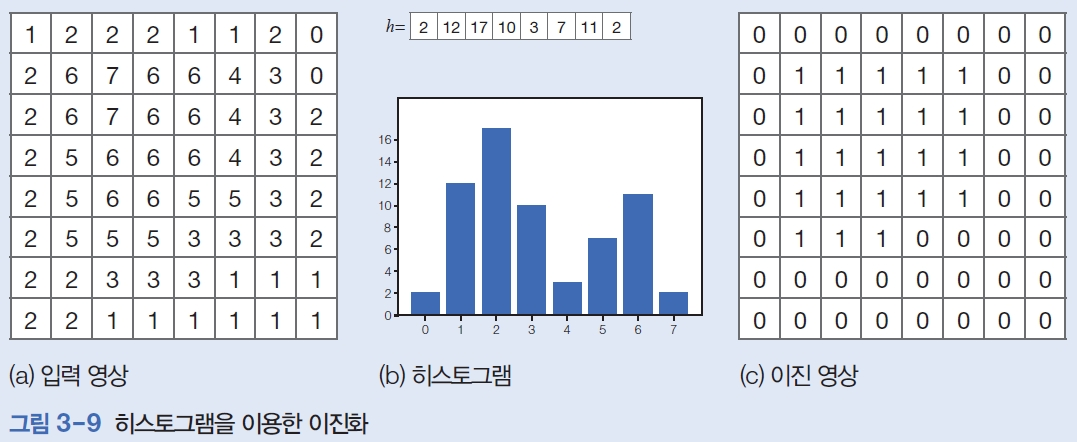

In [2]:
Image("그림 3-9.jpg", width=480)

##### 1 차원 히스토그램 : 그래프형태로 시각화 

(256, 1)
sum: 73800.0  = res: 73800


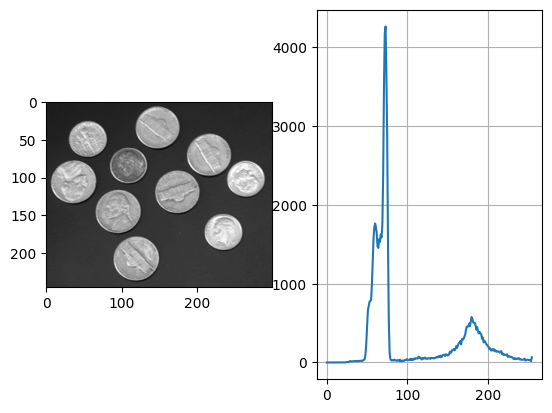

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
img = cv2.imread('coins.png')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hist = cv2.calcHist([img_gray], channels =[0], mask = None, histSize=[256],ranges=[0.0,256.0]) 
print(hist.shape)
print("sum:", np.sum(hist), " = res:", img_gray.shape[0]*img_gray.shape[1])
plt.subplot(1,2,1)
plt.imshow(img_gray, cmap='gray')
plt.subplot(1,2,2)
plt.plot(hist)
plt.grid()

#### 질문:  위의 히스토그램에서 이진화 임계치는 어디를 선택하면 좋을까?

##### 2차원 히스토그램 (이미지형태로 시각화)

(18, 25)


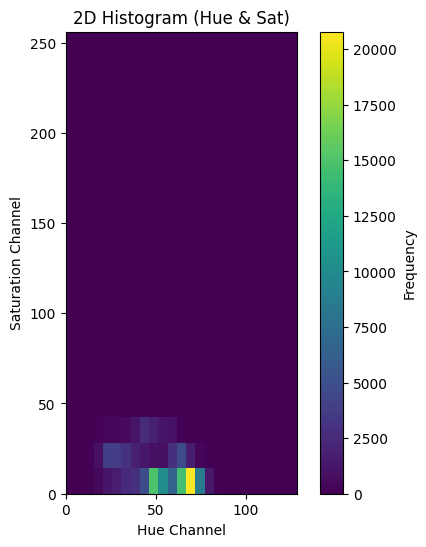

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
img_rgb = cv2.imread('Lena.png')
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2HSV)

# 2차원 히스토그램 계산 (0번: Blue, 1번: Green)
hist = cv2.calcHist([img_hsv], [0, 1], None, [180//10, 256//10], [0, 128, 0, 256])
print(hist.shape)
# 시각화 설정
plt.figure(figsize=(6, 6))
# 빈도수가 너무 낮으면 잘 안 보일 수 있으므로 로그 스케일이나 interpolation을 고려할 수 있습니다.
plt.imshow(hist, interpolation='nearest', origin='lower', extent=[0, 128, 0, 256])
plt.colorbar(label='Frequency')
plt.title('2D Histogram (Hue & Sat)')
plt.xlabel('Hue Channel')
plt.ylabel('Saturation Channel')
plt.show()

###  Otsu 알고리즘 

- 데이이터를 값을 기준으로 두개로 나누는 최적 기법 
- 최적의 기준
   - $ T = argmin_t V_{within} (t) = argmin_t (n_0 V_0(t) + n_1 V_1(t)) $
   - $ V_{within} $ 두개의 그룹 각각의 원소들의 분산. $V_{0}, V_{1}$
   - 모든 범위의 $t$ 값에 대하여 계산 하여 최소의 값이 되는 $t$를 선택 
- Ostu 는 이를 만족하는 계산효율적인 알고리즘을 제시함 (자세한 이론의 증명은 생략) 
   -  $V_{tot}(t) = V_{within} + V_{between} = Constant$ 라는 점을 이용
   -  $t$가 변화할 때 마다 재 계산을 해야하는 $V_{within}$ 을 최소화 하는 대신, $t$ 의 변화에 계산을 효과적으로 할 수 있는 $V_{between}$을 최소화 하는 알고리즘으로 변경   

126.0


(<Axes: title={'center': 'ostu'}>,
 Text(0.5, 1.0, 'ostu'),
 (-0.5, 299.5, 245.5, -0.5))

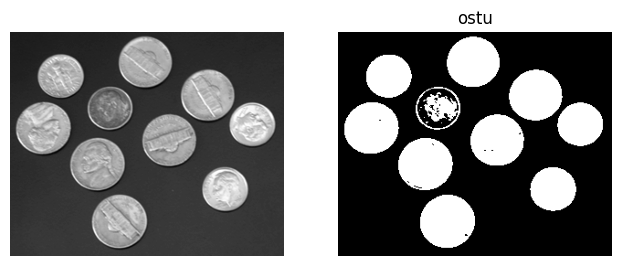

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
    
im_path = 'coins.png'
im_gray  = cv2.imread(im_path, cv2.IMREAD_GRAYSCALE)

# binarization
thres, im_bin = cv2.threshold(im_gray, thresh = 0 , maxval = 255, type = cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(thres) # 126

# ostue could not detect one (range around 100 - 120) 
#thres, im_bin2 = cv2.threshold(im_gray, thresh = thres - 30 , maxval = 255, type = cv2.THRESH_BINARY)
plt.figure(figsize=(12, 12))
plt.subplot(1,3,1), plt.imshow(im_gray, cmap='gray'), plt.axis('off')
plt.subplot(1,3,2), plt.imshow(im_bin, cmap='gray'), plt.title('ostu'), plt.axis('off')
#plt.subplot(1,3,3), plt.imshow(im_bin2, cmap='gray'), plt.title('manual'), plt.axis('off') 

### 질문: 오츄의 결과는 항상 만족스러운가?

## 3) 이진필터/형태학적 (Morphological)필터

- 이진화에 의한 결과는 화소별로 명확한 구분이 되었으나 이를 좀 더 그루핑하여 큰 영역으로 구성하는것이 이해를 하는데 필요함. 

### 연결 요소 

- 화소간의 연결성 (그루핑)을 따지는 방법 

- 4연결성 (상하좌우만 고려), 8 연결성 (상하좌우외에 대각선까지 고려)



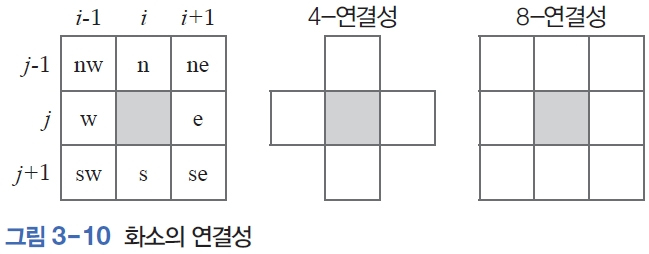

In [6]:
Image("그림 3-10.jpg", width=480)

### (이진) 모폴로지칼 필터 


#### 구성요소 

-  연결 여부를 따지는 주변화소들을 **구조요소**라고 하는데, 대표적으로 4연결 8연결이 있지만  이외에도 다양함. 




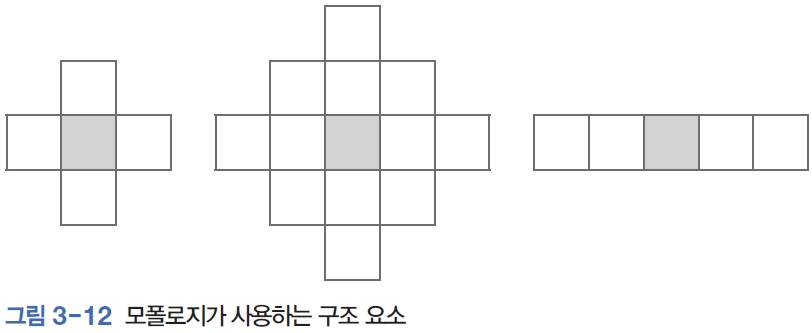

In [7]:
Image("그림 3-12.jpg", width=480)

#### 이진 몰포로지컬 연산 

여러가지가 있지만 가장 기본적인, 팽창, 침식, 열림, 닫힘 4가지만 다룸.

- 팽창: 현재 조사 화소가 1값을 갖는 화소와 연결되어 있으면 1로 함 => 영역이 넓어짐 
- 침식: 현재 조사 화소가 0값을 갖는 화소와 연결되어 있으면 0로 함 => 영역이 줄어듦.
- 닫힘: 팽창후 침식 적용 => 영역은 거의 동일하나 공간이 연결이 됨  
- 열림: 침식후 팽창 적용 => 영역은 거의 동일 하나 공간이 뚫림.

- **주의**: 팽창과 침식은 반대 과정이기는 하지만 수학적으로 정확히 역과정이 아님. 즉, 원래도 돌아 오지 않는다.



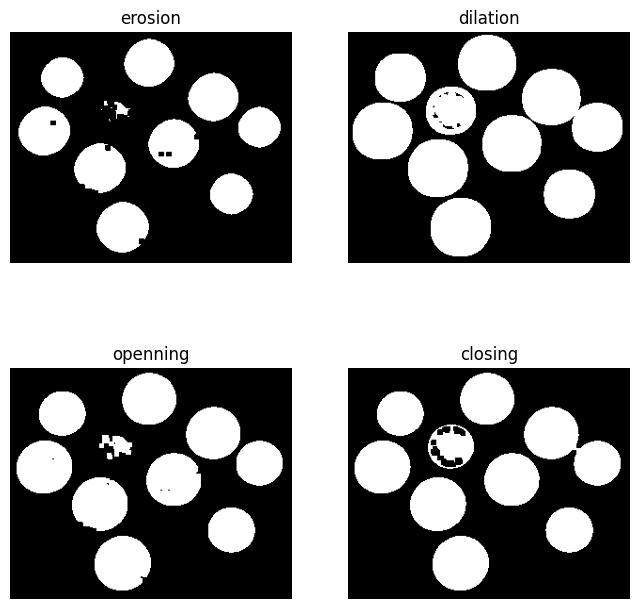

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
    
im_path = 'coins.png'
im_gray  = cv2.imread(im_path, cv2.IMREAD_GRAYSCALE)

# binarization
thres, im_bin = cv2.threshold(im_gray, thresh = 0 , maxval = 255, type = cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((5,5),np.uint8)
# or using API
# kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(5,5))

erosion = cv2.erode(im_bin,kernel,iterations = 1)
dilation = cv2.dilate(im_bin,kernel,iterations = 1)
opening = cv2.morphologyEx(im_bin, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(im_bin, cv2.MORPH_CLOSE, kernel)
plt.figure(figsize=(8, 8))
plt.subplot(2,2,1), plt.imshow(erosion, cmap='gray'), plt.title('erosion'), plt.axis('off')
plt.subplot(2,2,2), plt.imshow(dilation, cmap='gray'), plt.title('dilation'), plt.axis('off')
plt.subplot(2,2,3), plt.imshow(opening, cmap='gray'), plt.title('openning'), plt.axis('off')
plt.subplot(2,2,4), plt.imshow(closing, cmap='gray'), plt.title('closing'), plt.axis('off')
plt.show() 


###  응용 

- 위의 결과를 바탕으로 동전 영역을 구분하고, contour를 만들어 갯수를 세고, 크기를 계산하고, 모양을 예측할 수 있음.
-  예를 들어 contour 관련 함수들 참고
    -  contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    - cv2.drawContours(mask, contours, -1, 255, -1) # Fill with white (255)

### 끝